# Prac 07.2

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [1]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

In [2]:
import zipfile
with zipfile.ZipFile('/content/archive (5).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
print('Done!')

Done!


### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

Total samples: 39209
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


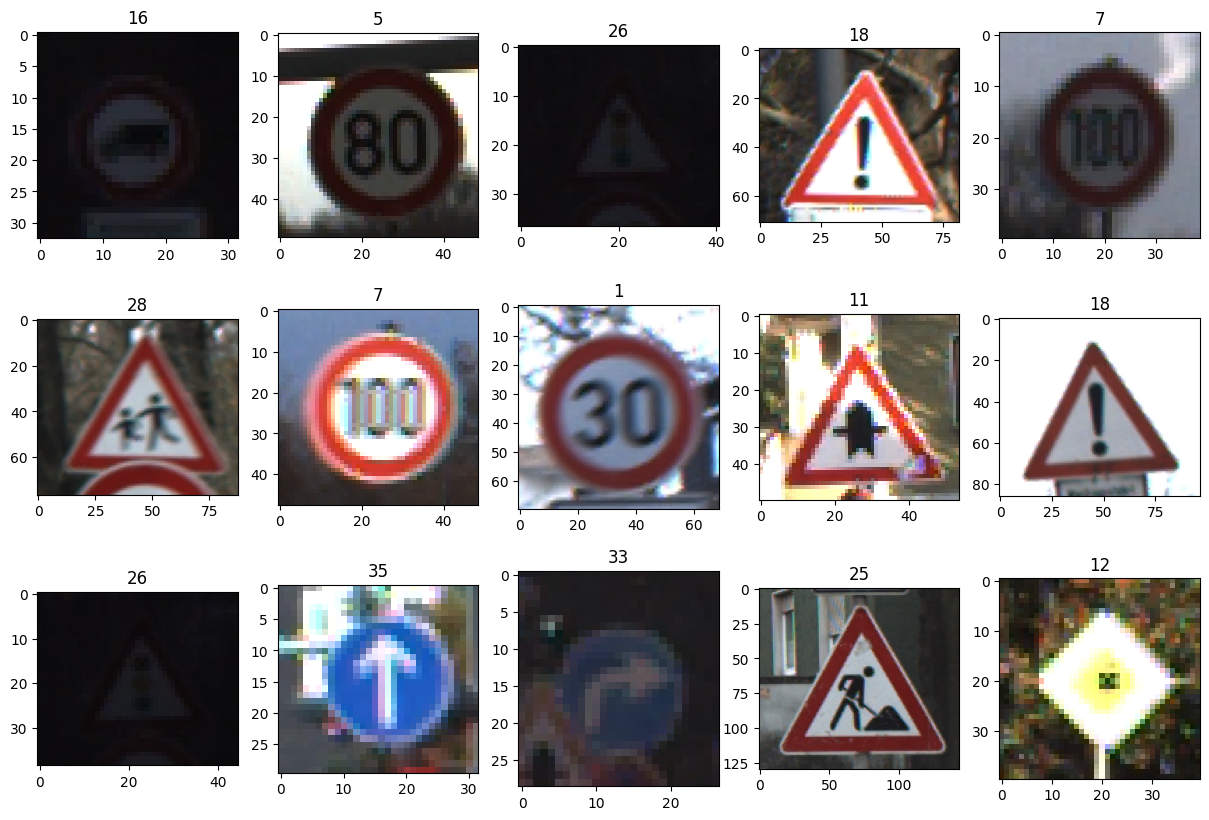

In [4]:
# Load the training labels
root = '/content/'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples
num_samples = len(data)
print(f'Total samples: {num_samples}')
print(data.head())

# Show random data samples
for ii in range(15):
    idx = np.random.randint(0, num_samples)
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 5, ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])
plt.show()

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [5]:
# Extract class identifiers
# Hint: Check the csv
# Extract class identifiers
ids = data['ClassId'].tolist()


Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

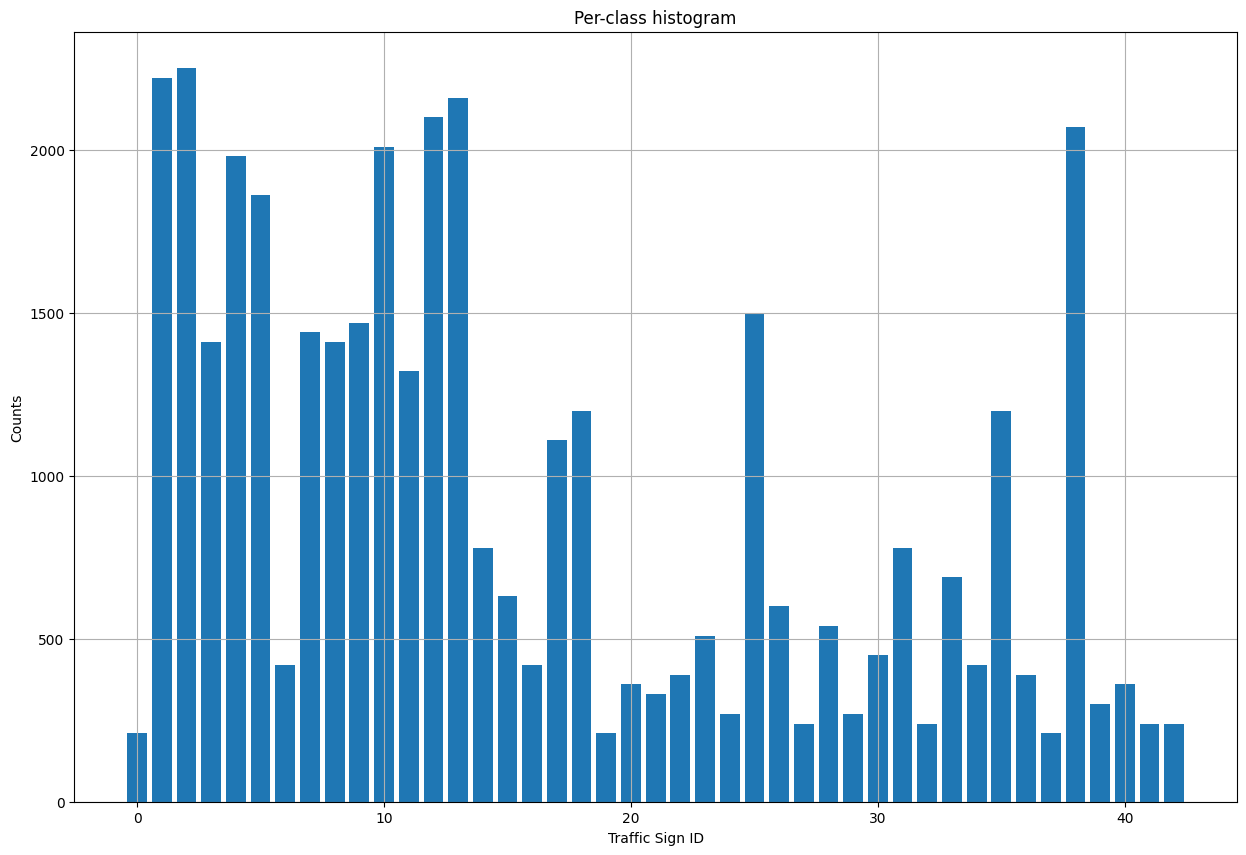

Least represented classes: [(0, 210), (19, 210), (37, 210), (27, 240), (32, 240)]
Most represented classes: [(38, 2070), (12, 2100), (13, 2160), (1, 2220), (2, 2250)]


In [9]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')
plt.title('Per-class histogram')
plt.show()


### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?

No, the dataset is not balanced. The class distribution is uneven, as shown in the histogram: some classes contain noticeably more samples than others. This means the number of training examples varies significantly across categories.
* Are there any classes that are (significantly) over-represented or under-represeneted?

Yes. Certain classes, such as speed limit signs, are over-represented because they are more common in real-world traffic scenarios. At the same time, some classes have much fewer samples and are under-represented. Such imbalance may influence the classifier’s performance, since the model can become more biased toward the classes with larger amounts of training data.